[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/00_simulation.ipynb)

# 00 — Generate the simulation data



**Purpose.** Run the three simulation stages end to end and explain what each

one does, so the files everything downstream reads are reproducible from this

notebook alone.



**Inputs.** `configs/simulation.yaml` — every path and every setting comes from

there. Nothing is hard-coded here.



**Outputs.**


| stage | writes |
|---|---|
| scenario | `data/external/ue_positions.csv`, `data/external/scenario.json` |
| radio map | `data/interim/radio_map.npz` |
| MDT | `data/interim/mdt.csv` |


**Before you run.** The radio map and the MDT stages need a CUDA GPU and the

Sionna-RT extra (`task sync:rt`). The radio map stage is the slow one — it traces

rays for every transmitter on every band, and how long that takes depends on the

fidelity settings in the config.



The equivalent from a shell is `task simulation`, which runs the same three

stages in the same order.

## 0. Environment



Run this section first, wherever you are.



**Locally** it only walks up to the project root and makes it the working

directory, so the root-relative paths in `configs/simulation.yaml` resolve the

same way they do for `task simulation`. Nothing is installed.



**In Colab** it also clones the repository, puts it on `sys.path` so `import src`

works without an editable install, and installs the packages Colab does not

already ship. Note that `data/` is DVC-tracked and therefore *not* part of the

clone.

In [1]:
# --- Environment bootstrap -------------------------------------------------

REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"

BRANCH = "main"

SUBDIR = "."  # project root inside the repository



# (import name, pip name). Colab already ships numpy, pandas, matplotlib and

# seaborn, so only these are installed.

COLAB_PACKAGES = [("hydra", "hydra-core"), ("sionna", "sionna-rt")]



import importlib.util

import os

import subprocess

import sys

from pathlib import Path



try:

    import google.colab  # noqa: F401



    IN_COLAB = True

except ImportError:

    IN_COLAB = False



if IN_COLAB:

    checkout = Path("/content") / Path(REPO_URL).stem

    if not checkout.exists():

        subprocess.run(

            ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(checkout)],

            check=True,

        )

    root = (checkout / SUBDIR).resolve()

    missing = [pip for mod, pip in COLAB_PACKAGES if importlib.util.find_spec(mod) is None]

    if missing:

        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

else:

    # JupyterLab starts the kernel in notebooks/; walk up to the project root.

    root = Path.cwd()

    while not (root / "pyproject.toml").exists() and root != root.parent:

        root = root.parent



os.chdir(root)

if str(root) not in sys.path:

    sys.path.insert(0, str(root))  # makes `import src` work without an editable install



# Extra Hydra overrides consumed by load_config() in section 1.

CONFIG_OVERRIDES: list[str] = []



print(f"project root: {root}   colab: {IN_COLAB}")

project root: D:\Projects\band-tilt   colab: False


## 1. Setup



Compose the config and seed everything. Every notebook starts the same way, so

that a cell copied between notebooks behaves identically.

In [2]:
%load_ext autoreload
%autoreload 2

from functools import partial

import pandas as pd

from src.config import load_config
from src.utils.plotting import save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()

# Figures land here so they can be viewed without rerunning the notebook; skipped on Colab.
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/00_simulation"))

pd.set_option("display.max_columns", 50)
cfg.simulation.output

{'ue_file': 'data/external/ue_positions.csv', 'manifest_file': 'data/external/scenario.json', 'radio_map_file': 'data/interim/radio_map.npz', 'mdt_file': 'data/interim/mdt.csv'}

In [3]:
import dataclasses
import json
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Every render in this notebook looks straight down. A square resolution frames
# the scene the same way whichever axis mitsuba measures the field of view on.
RENDER_FOV = 45.0
RENDER_RESOLUTION = (900, 900)
RENDER_SAMPLES = 128


def top_down_camera(bounds, centre=None, span=None, margin=1.08):
    """Build a camera above ``centre`` looking straight down.

    Args:
        bounds: Scene extent, used for the default framing and the ground height.
        centre: ``(x, y)`` to look at. Defaults to the centre of ``bounds``.
        span: Ground width to cover in metres. Defaults to the longer side.
        margin: Slack left around ``span``.
    """
    from sionna.rt import Camera

    if centre is None:
        centre = (0.5 * (bounds.min_x + bounds.max_x), 0.5 * (bounds.min_y + bounds.max_y))
    if span is None:
        span = max(bounds.width_m, bounds.depth_m)
    height = bounds.max_z + 0.5 * span * margin / math.tan(math.radians(0.5 * RENDER_FOV))
    return Camera(
        position=[float(centre[0]), float(centre[1]), float(height)],
        look_at=[float(centre[0]), float(centre[1]), float(bounds.min_z)],
    )


def render(scene, camera, title, name=None, **kwargs):
    """Render ``scene`` at the shared fidelity, title it, save it under ``name`` if given, and show it."""
    figure = scene.render(
        camera=camera,
        fov=RENDER_FOV,
        resolution=RENDER_RESOLUTION,
        num_samples=RENDER_SAMPLES,
        **kwargs,
    )
    figure.axes[0].set_title(title)
    figure.tight_layout()  # sionna lays the figure out before the title exists
    if name is not None:
        save_fig(figure, name)
    plt.show()

## 2. The node layout — a one-off, not part of a run



Before any of this can run, the config needs a table of cells: where each mast

stands, which way it points, and what tilt it starts at on each band.



That table is generated once, by `task simulation:layout`, and pasted into

`configs/simulation.yaml` under `transmitters.cells`. The generator lays nodes

out on a square lattice about the middle of the scene, then walks outward from

each ideal position until it finds a tile that is open ground with an open

surround, confirms that tile with a downward ray, and stands the mast a fixed

height above the ground it measured. A node with no such tile within reach makes

the generator fail rather than putting a mast on a roof.



It is deliberately not re-run here. The masts are surveyed against the

undisturbed city and then held fixed: perturbations model what we get wrong

about the city, not something an operator reacts to, and a real mast stays where

it was surveyed even when the survey turns out to have been wrong.

In [4]:
from src.simulation import transmitter

cells = transmitter.load(cfg)

pd.DataFrame(
    [
        {
            "name": cell.name,
            "x": cell.x,
            "y": cell.y,
            "z": cell.z,
            "azimuth_deg": cell.azimuth_deg,
            **{f"tilt_{band}": cell.tilt_for(band).baseline_deg for band in cell.tilt},
        }
        for cell in cells
    ]
)

,name,x,y,z,azimuth_deg,tilt_b2600,tilt_b1800,tilt_b700
0,n0c0,-380.34,-489.80,30.0,0.0,8.0,6.0,4.0
1,n0c1,-380.34,-489.80,30.0,120.0,8.0,6.0,4.0
2,n0c2,-380.34,-489.80,30.0,240.0,8.0,6.0,4.0
3,n1c0,-465.72,352.86,30.0,0.0,8.0,6.0,4.0
4,n1c1,-465.72,352.86,30.0,120.0,8.0,6.0,4.0
5,n1c2,-465.72,352.86,30.0,240.0,8.0,6.0,4.0
6,n2c0,257.15,-470.78,30.0,0.0,8.0,6.0,4.0
7,n2c1,257.15,-470.78,30.0,120.0,8.0,6.0,4.0
8,n2c2,257.15,-470.78,30.0,240.0,8.0,6.0,4.0
9,n3c0,192.83,229.83,30.0,0.0,8.0,6.0,4.0


## 3. Stage 1 — the scenario



A scenario is one version of the city together with the people in it. It is

drawn once and then held fixed, so that later stages can change tilt with

nothing else moving underneath. That is what makes the KPIs a function of tilt.



What the stage does, in order:



1. **Load the scene.** The city geometry ships with Sionna-RT.

2. **Perturb the buildings.** Some are removed, others are nudged in height,

   position and rotation. This stands for survey error — the footprints a scene

   is built from are never exactly right — rather than for the city changing.

3. **Raster the scene.** A square grid is laid over it and rays are cast

   straight down inside every tile, which says how much of the tile is open

   ground and how tall whatever stands there is.

4. **Place the demand hotspots.** Their centres are drawn towards densely built

   areas, because that is both where users gather and where propagation is

   hardest. That tension is the problem the project is about.

5. **Build the time schedule.** Demand rises and falls across the day and

   carries over from one interval to the next, so load has structure rather than

   being noise a configuration cannot be tuned against.

6. **Draw the UEs.** Each interval gets a fresh crowd, drawn from the hotspots

   and from a uniform background, with every position checked to be on open

   ground and inside the region of interest.



It writes the UE table and a manifest that records what this scenario is, so it

can be regenerated and so the train/validation/test split can be made between

whole scenarios.

In [5]:
from src.simulation import scenario



ue_file, manifest_file = scenario.generate(cfg)

jitc_llvm_init(): LLVM API initialization failed ..


scenario: scn_b2779850236462be
removed:  20 buildings   jittered: 40
grid:     74 x 61 tiles, 4266 eligible inside a 0.0 m margin
hotspots: 4
time:     168 intervals of 3600 s, 40-80 UEs each
demand:   hotspots hold 79% to 94% of the population across intervals
ue:       9939 rows at z=1.5 m
densest decile holds 57.0% of UEs
csv:      data\external\ue_positions.csv
manifest: data\external\scenario.json


In [6]:
manifest = json.loads(Path(manifest_file).read_text(encoding="utf-8"))

pd.DataFrame(
    {
        "value": {
            "scenario_id": manifest["scenario_id"],
            "seed": manifest["seed"],
            **manifest["grid"],
            **manifest["area"],
            "n_intervals": manifest["time"]["n_intervals"],
            "buildings_removed": len(manifest["perturbation"]["removed"]),
            "buildings_jittered": len(manifest["perturbation"]["jittered"]),
            "ue_rows": manifest["ue"]["rows"],
        }
    }
)

,value
scenario_id,scn_b2779850236462be
seed,42
launch_z,108.57
n_cols,74
n_rows,61
origin_x,-805.583679
origin_y,-688.600647
tile_size_m,20.0
margin_m,0.0
max_x,669.882751


In [7]:
pd.DataFrame(manifest["density"]["hotspots"])

,rotation_rad,sigma_major_m,sigma_minor_m,x,y
0,1.319400,150.457166,57.976418,409.452166,56.673197
1,0.875041,134.123766,116.425166,72.254354,-343.027986
2,2.633298,130.639949,40.326218,-259.405204,-369.565567
3,2.962107,144.215391,78.839084,-86.681146,183.262837


In [8]:
ue = pd.read_csv(ue_file)

print(f"{len(ue):,} rows x {ue.shape[1]} columns")
print(ue.dtypes.to_string())
ue.head()

9,939 rows x 8 columns
t_index        int64
t_s          float64
x            float64
y            float64
z            float64
tile_col       int64
tile_row       int64
component      int64


,t_index,t_s,x,y,z,tile_col,tile_row,component
0,0,0.0,557.366,-441.740,1.5,68,12,-1
1,0,0.0,442.812,76.556,1.5,62,38,0
2,0,0.0,26.025,-367.147,1.5,41,16,1
3,0,0.0,-269.153,117.087,1.5,26,40,3
4,0,0.0,401.564,206.385,1.5,60,44,0


In [9]:
ue.describe().T

,count,mean,std,min,25%,50%,75%,max
t_index,9939.0,82.744542,48.259498,0.000,41.0000,81.000,126.0000,167.000
t_s,9939.0,297880.350136,173734.191398,0.000,147600.0000,291600.000,453600.0000,601200.000
x,9939.0,-6.250199,290.249315,-805.441,-219.2830,-29.715,186.0905,669.091
y,9939.0,-139.603278,294.204325,-687.555,-383.3145,-227.959,141.5880,511.250
z,9939.0,1.500000,0.000000,1.500,1.5000,1.500,1.5000,1.500
tile_col,9939.0,39.467049,14.511506,0.000,29.0000,38.000,49.0000,73.000
tile_row,9939.0,26.952410,14.707733,0.000,15.0000,23.000,41.0000,59.000
component,9939.0,1.294195,1.306815,-1.000,0.0000,1.000,2.0000,3.000


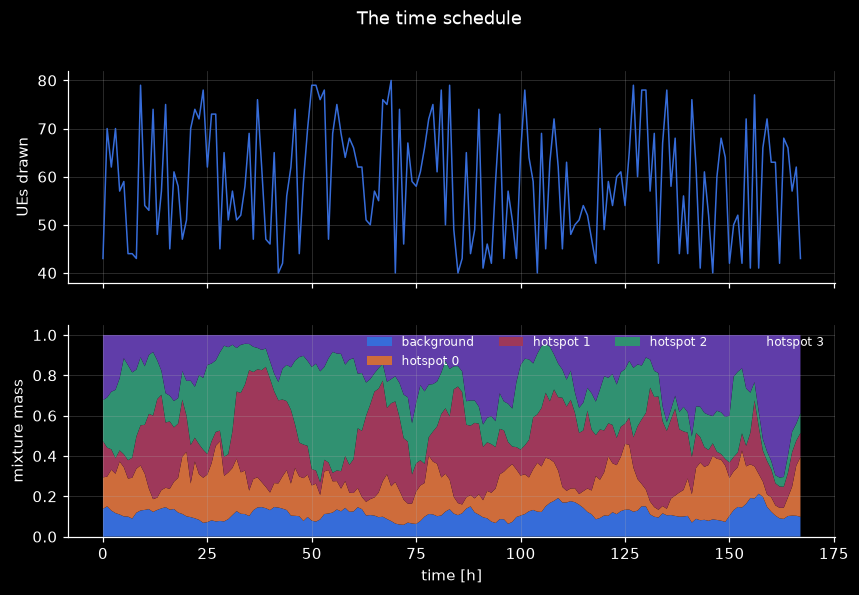

In [10]:
hours = np.asarray(manifest["time"]["t_s"]) / 3600.0
mass = np.asarray(manifest["time"]["component_mass"])

figure, axes = plt.subplots(2, 1, figsize=(9.0, 5.5), sharex=True)
axes[0].plot(hours, manifest["time"]["count"], lw=1.0)
axes[0].set_ylabel("UEs drawn")
axes[1].stackplot(
    hours,
    mass.T,
    labels=["background"] + [f"hotspot {index}" for index in range(mass.shape[1] - 1)],
)
axes[1].set_ylabel("mixture mass")
axes[1].set_xlabel("time [h]")
axes[1].legend(loc="upper right", ncol=4, fontsize=8)
figure.suptitle("The time schedule")
save_fig(figure, "time_schedule")
plt.show()

### The scene, before and after the perturbation

`perturb.apply` edits in place and there is no clone, so the delivered scene and
the perturbed one are two separate loads. Both are rendered from the same camera
so the pair can be compared.

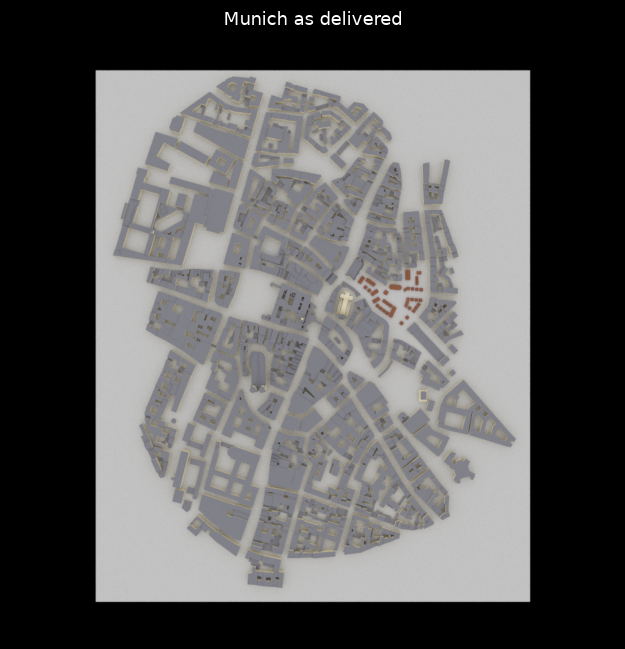

In [11]:
from src.simulation import perturb, seeds
from src.simulation import scene as scene_module
from src.simulation.perturb import PerturbSpec
from src.simulation.scene import SceneSpec

scene_spec = SceneSpec.from_config(cfg)
clean_scene, delivered = scene_module.load(scene_spec)
camera = top_down_camera(delivered)

render(clean_scene, camera, "Munich as delivered", name="scene_delivered")

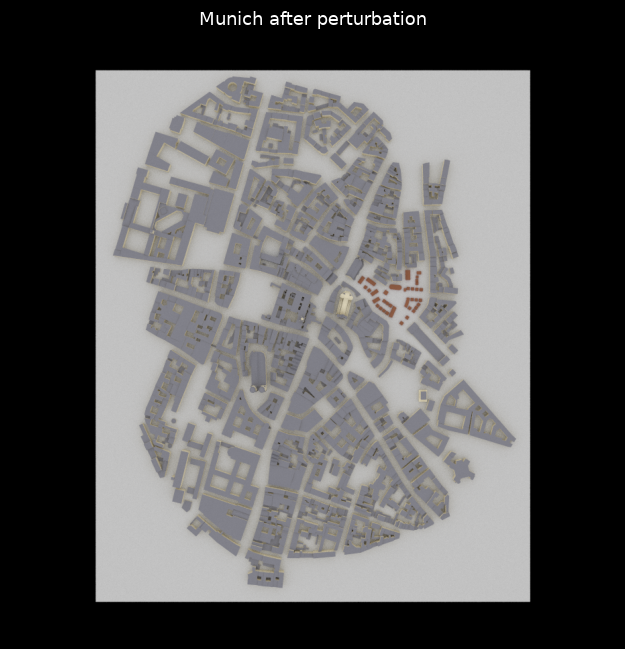

In [12]:
perturbed_scene, _ = scene_module.load(scene_spec)
report = perturb.apply(perturbed_scene, PerturbSpec.from_config(cfg), seeds.stream(cfg, "scene"))
bounds = dataclasses.replace(
    delivered, max_z=max(delivered.max_z, scene_module.bounds_of(perturbed_scene).max_z)
)

render(perturbed_scene, camera, "Munich after perturbation", name="scene_perturbed")

In [13]:
print(f"removed {len(report.removed)} buildings, jittered {len(report.jittered)}")

pd.DataFrame(
    {"removed": pd.Series(report.removed), "jittered": pd.Series(report.jittered)}
).head(10)

removed 20 buildings, jittered 40


,removed,jittered
0,element_645,element_481
1,Pfisterm_hle,element_653
2,element_1169,element_670
3,element_134,element_752
4,element_970,element_533
5,element_687,element_1016
6,element_742,element_007
7,element_185,element_326
8,element_208,element_657
9,element_269,element_638


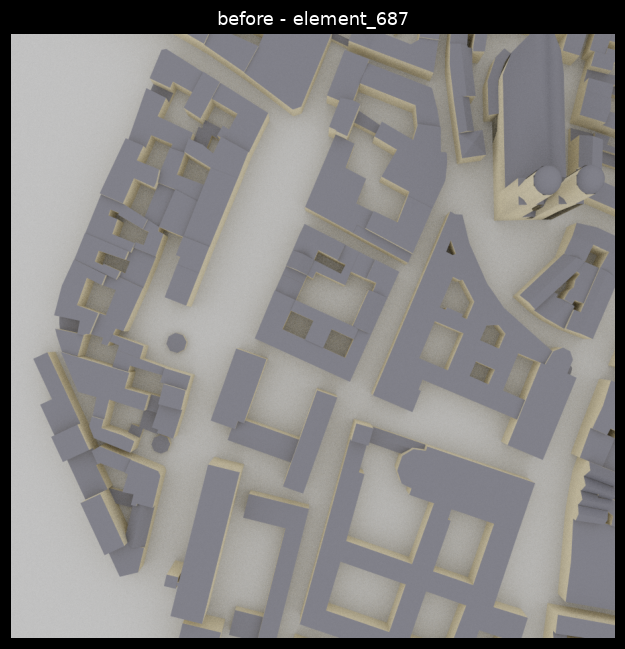

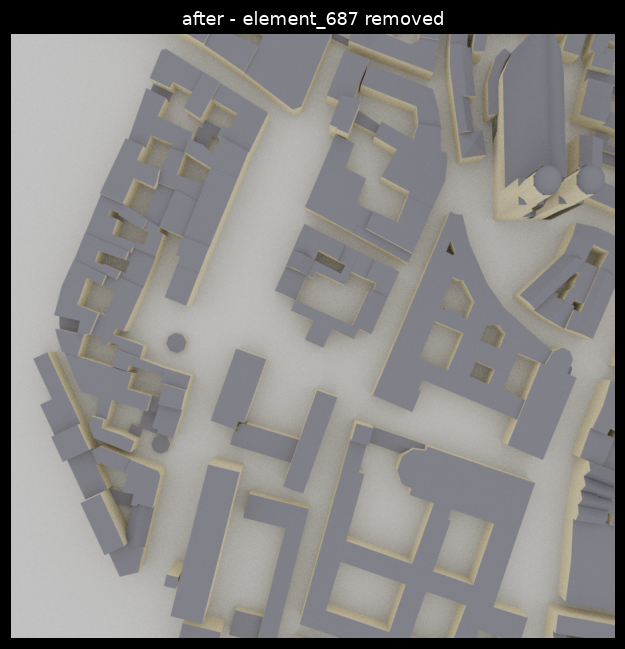

In [14]:
# At scene scale a removed building is a few pixels across, so the camera drops
# onto the largest one, framed at four times its own footprint.
groups = perturb.buildings(clean_scene)


def footprint(name):
    """Return the (min, max) xy corners spanned by a building's parts."""
    low = np.full(2, np.inf)
    high = np.full(2, -np.inf)
    for part in groups[name]:
        box = part.mi_mesh.bbox()
        low = np.minimum(low, [box.min.x, box.min.y])
        high = np.maximum(high, [box.max.x, box.max.y])
    return low, high


corners = {name: footprint(name) for name in report.removed}
target = max(corners, key=lambda name: float(np.max(corners[name][1] - corners[name][0])))
low, high = corners[target]
zoom = top_down_camera(
    delivered, centre=0.5 * (low + high), span=max(4.0 * float(np.max(high - low)), 120.0)
)

render(clean_scene, zoom, f"before - {target}", name="scene_before_removed_building")
render(perturbed_scene, zoom, f"after - {target} removed", name="scene_after_removed_building")

## 4. Stage 2 — the radio map



The radio map is the ground truth: how strong a signal every grid tile would

receive from every transmitter.



1. **Rebuild the same city.** The scene is loaded and perturbed again from the

   same seed, so it matches the scenario exactly.

2. **Install the radio materials.** They are swapped for plain ones that do not

   recompute themselves when the carrier changes, which is what lets the low

   band be solved at all and what keeps this scenario's material draw.

3. **Add the transmitters.** Each cell is placed at the tilt the config gives

   it *for the band being solved*, so two bands on the same mast can point

   differently. That freedom is the thing being optimised.

4. **Solve.** The solver traces rays from every transmitter over the same grid

   the UEs were binned into, and the result is turned into RSRP.



One band at a time, because a scene carries a single carrier frequency. Tiles no

ray reaches are left empty rather than set to zero — no coverage and no

measurement are different things.

In [15]:
from src.simulation import radio



radio_map_file = radio.solve(cfg)

   b2600  tilt  8.0- 8.0 deg     1.4s  tiles reached  90.9%  best server -201.3 to  -53.1 dBm
   b1800  tilt  6.0- 6.0 deg     1.3s  tiles reached  90.4%  best server -157.5 to  -51.4 dBm
    b700  tilt  4.0- 4.0 deg     1.2s  tiles reached  90.9%  best server -172.8 to  -44.4 dBm
radio map: data\interim\radio_map.npz  shape (3, 12, 61, 74) [band, tx, row, col]


In [16]:
with np.load(radio_map_file, allow_pickle=False) as archive:
    radio_map_data = {key: archive[key] for key in archive.files}

pd.DataFrame(
    [
        {"key": key, "shape": str(value.shape), "dtype": str(value.dtype)}
        for key, value in radio_map_data.items()
    ]
)

,key,shape,dtype
0,rsrp_dbm,"(3, 12, 61, 74)",float32
1,band_hz,"(3,)",float64
2,band_label,"(3,)",<U5
3,tilt_deg,"(3, 12)",float64
4,tx_name,"(12,)",<U4
5,origin_x,(),float64
6,origin_y,(),float64
7,tile_size_m,(),float64
8,n_cols,(),int64
9,n_rows,(),int64


In [17]:
rsrp = radio_map_data["rsrp_dbm"]
bands = [str(label) for label in radio_map_data["band_label"]]
tx_names = [str(name) for name in radio_map_data["tx_name"]]
n_rows, n_cols = int(radio_map_data["n_rows"]), int(radio_map_data["n_cols"])
tile_size = float(radio_map_data["tile_size_m"])
extent = [
    float(radio_map_data["origin_x"]),
    float(radio_map_data["origin_x"]) + n_cols * tile_size,
    float(radio_map_data["origin_y"]),
    float(radio_map_data["origin_y"]) + n_rows * tile_size,
]

with warnings.catch_warnings():
    # A tile no ray reached is all-NaN, and nanmax over one warns.
    warnings.simplefilter("ignore", RuntimeWarning)
    best_server = np.stack([np.nanmax(rsrp[index], axis=0) for index in range(len(bands))])

pd.DataFrame(
    {
        "cells_reached": np.isfinite(best_server).mean(axis=(1, 2)),
        "rsrp_min": np.nanmin(best_server, axis=(1, 2)),
        "rsrp_median": np.nanmedian(best_server, axis=(1, 2)),
        "rsrp_max": np.nanmax(best_server, axis=(1, 2)),
    },
    index=bands,
)

,cells_reached,rsrp_min,rsrp_median,rsrp_max
b2600,0.908728,-201.329437,-84.121582,-53.123806
b1800,0.904076,-157.470245,-79.719368,-51.393936
b700,0.909171,-172.800018,-71.851440,-44.410389


In [18]:
pd.DataFrame(radio_map_data["tilt_deg"].T, index=tx_names, columns=bands)

,b2600,b1800,b700
n0c0,8.0,6.0,4.0
n0c1,8.0,6.0,4.0
n0c2,8.0,6.0,4.0
n1c0,8.0,6.0,4.0
n1c1,8.0,6.0,4.0
n1c2,8.0,6.0,4.0
n2c0,8.0,6.0,4.0
n2c1,8.0,6.0,4.0
n2c2,8.0,6.0,4.0
n3c0,8.0,6.0,4.0


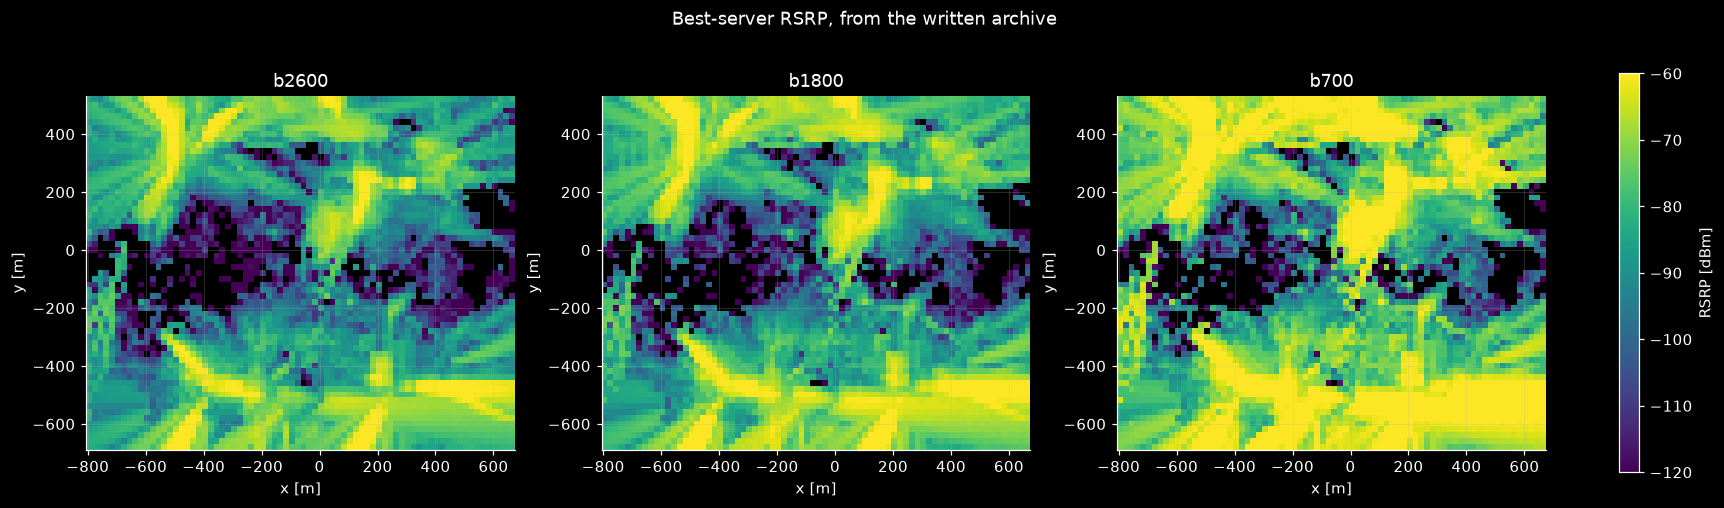

In [19]:
# One scale for every panel, and the same limits as the ray-traced views below,
# so the bands compare against each other and against the render.
RSRP_LIMITS = (-120.0, -60.0)

figure, axes = plt.subplots(1, len(bands), figsize=(5.2 * len(bands), 4.6), constrained_layout=True)
axes = np.atleast_1d(axes)
for axis, index, band in zip(axes, range(len(bands)), bands):
    image = axis.imshow(
        best_server[index],
        origin="lower",
        extent=extent,
        aspect="equal",
        vmin=RSRP_LIMITS[0],
        vmax=RSRP_LIMITS[1],
    )
    axis.set_title(band)
    axis.set_xlabel("x [m]")
    axis.set_ylabel("y [m]")
figure.colorbar(image, ax=axes, label="RSRP [dBm]", shrink=0.85)
figure.suptitle("Best-server RSRP, from the written archive")
save_fig(figure, "radio_map_best_server")
plt.show()

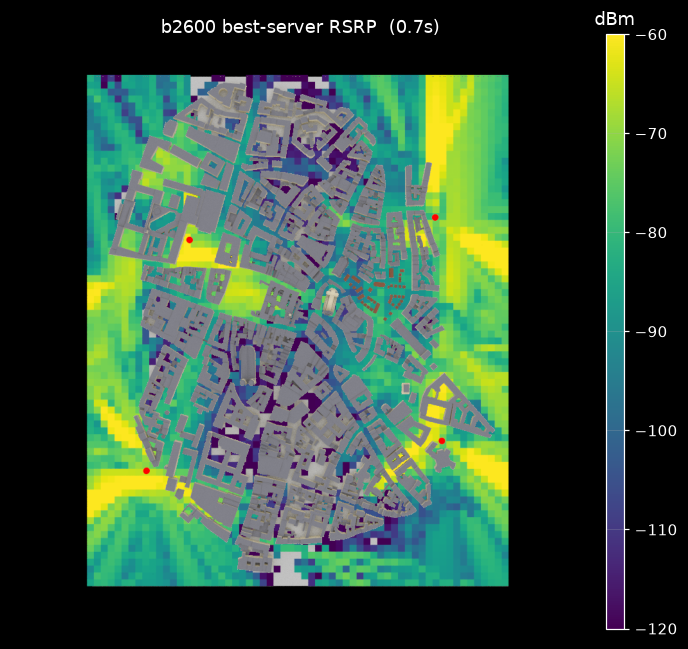

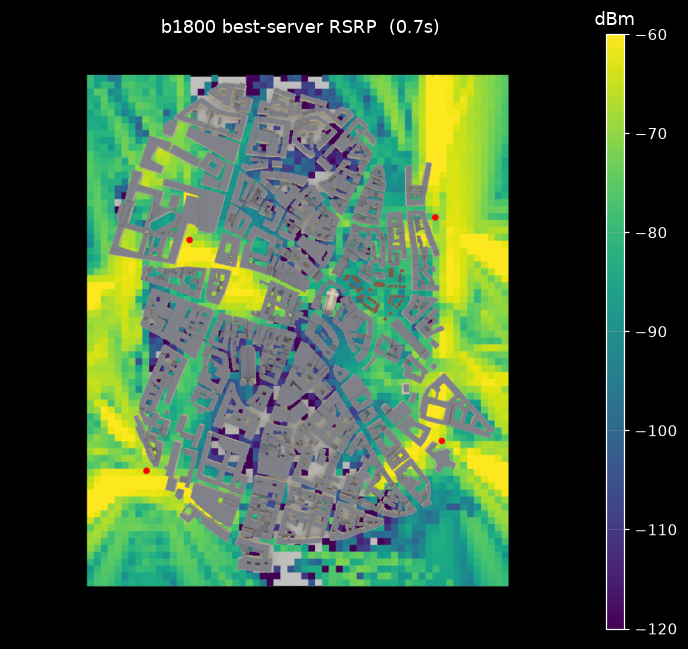

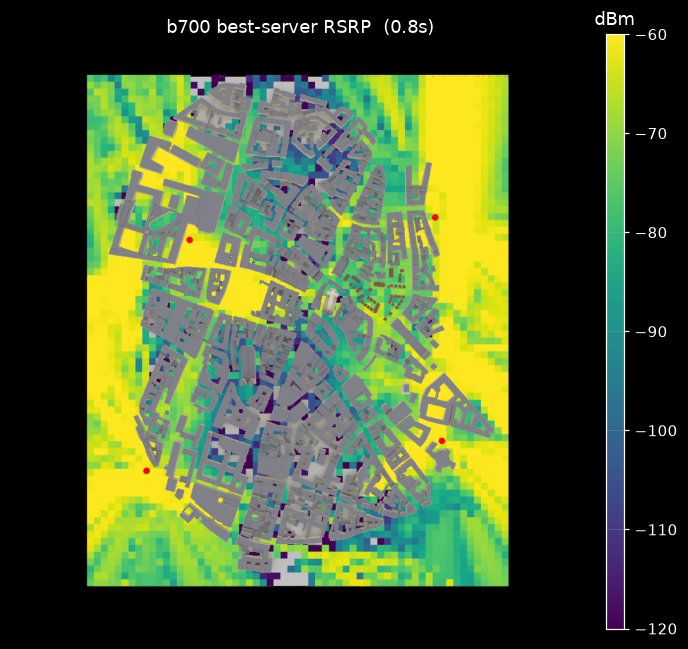

In [20]:
from src.simulation.materials import MaterialSpec

radio.configure_arrays(perturbed_scene, cfg)
solver_spec = radio.SolverSpec.from_config(cfg)
material_spec = MaterialSpec.from_config(cfg)

for entry in cfg.simulation.radio_map.bands:
    band = radio.Band.from_config(entry)
    _, elapsed, _, live_map = radio.solve_band(
        perturbed_scene,
        cells,
        band,
        solver_spec,
        material_spec,
        seeds.stream(cfg, "materials"),
        seeds.stream(cfg, "solver"),
        manifest["grid"],
        float(cfg.simulation.ue.height_m),
        float(cfg.simulation.antenna.power_rs),
    )
    render(
        perturbed_scene,
        camera,
        f"{band.name} best-server RSRP  ({elapsed:.1f}s)",
        name=f"radio_map_render_{band.name}",
        radio_map=live_map,
        rm_metric="rss",
        rm_vmin=RSRP_LIMITS[0],
        rm_vmax=RSRP_LIMITS[1],
        rm_show_color_bar=True,
    )

## 5. Stage 3 — the MDT



MDT is what a handset reports, as opposed to what is true.



1. **Look each UE up in the map.** Its grid tile gives the clean signal strength

   from every cell-band pair.

2. **Add measurement error.** This is receiver error only. The shadowing that

   fading models stand in for is already there, computed from the actual

   buildings, so adding fading on top would count them twice.

3. **Censor.** Part of what is left is dropped, because a real handset does not

   report every cell it can hear. The strongest cell and its close rivals are

   never dropped, so the coverage KPIs cannot be moved by censoring.



The clean map from stage 2 is written separately and is not touched here: it is

the label a surrogate learns, and noising a label would teach a model to predict

noise.

In [21]:
from src.simulation import mdt



mdt_file = mdt.build(cfg)

ue:        9701 rows x 36 measurements (238 no-signal UEs dropped)
intervals: 168, 58 UEs per interval on average
reachable:  40.0% of measurements had a path
reported:   73.7% of those survived censoring
per ue:    1 to 26 cells reported
mdt:       data\interim\mdt.csv


In [22]:
mdt_frame = pd.read_csv(mdt_file)
measurement_columns = [column for column in mdt_frame.columns if column.startswith("rsrp_")]

print(
    f"{len(mdt_frame):,} rows: {mdt_frame.shape[1] - len(measurement_columns)} position "
    f"+ {len(measurement_columns)} measurement columns"
)
print(f"{len(ue) - len(mdt_frame):,} UEs no transmitter reached were dropped")
mdt_frame.head()

9,701 rows: 7 position + 36 measurement columns
238 UEs no transmitter reached were dropped


,t_index,t_s,x,y,z,tile_col,tile_row,rsrp_n0c0_b2600,rsrp_n0c0_b1800,rsrp_n0c0_b700,rsrp_n0c1_b2600,rsrp_n0c1_b1800,rsrp_n0c1_b700,rsrp_n0c2_b2600,rsrp_n0c2_b1800,rsrp_n0c2_b700,rsrp_n1c0_b2600,rsrp_n1c0_b1800,rsrp_n1c0_b700,rsrp_n1c1_b2600,rsrp_n1c1_b1800,rsrp_n1c1_b700,rsrp_n1c2_b2600,rsrp_n1c2_b1800,rsrp_n1c2_b700,rsrp_n2c0_b2600,rsrp_n2c0_b1800,rsrp_n2c0_b700,rsrp_n2c1_b2600,rsrp_n2c1_b1800,rsrp_n2c1_b700,rsrp_n2c2_b2600,rsrp_n2c2_b1800,rsrp_n2c2_b700,rsrp_n3c0_b2600,rsrp_n3c0_b1800,rsrp_n3c0_b700,rsrp_n3c1_b2600,rsrp_n3c1_b1800,rsrp_n3c1_b700,rsrp_n3c2_b2600,rsrp_n3c2_b1800,rsrp_n3c2_b700
0,0,0.0,557.366,-441.740,1.5,68,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-64.220,-62.52,-102.235,-98.725,-89.087,-117.571,NaN,-101.269,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0.0,442.812,76.556,1.5,62,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-142.285,NaN,-131.401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-86.641,-92.159,-81.251,-127.262,NaN,-104.181,-112.546,NaN,NaN
2,0,0.0,26.025,-367.147,1.5,41,16,-92.68,-98.867,NaN,-128.093,NaN,-110.767,-132.492,-125.602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-134.688,-130.575,NaN,-86.469,-93.500,-82.646,NaN,-132.323,-123.118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,0.0,-269.153,117.087,1.5,26,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-111.022,-105.027,-101.642,-134.478,NaN,-104.336,-112.593,NaN,-104.221,NaN,-151.752,-141.52,-114.302,NaN,-94.060,-146.361,NaN,-134.412,NaN,NaN,NaN,-146.061,NaN,NaN,NaN,NaN,NaN
4,0,0.0,401.564,206.385,1.5,60,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-80.157,-77.322,-67.283,-126.572,-125.008,NaN,-126.068,NaN,-114.22


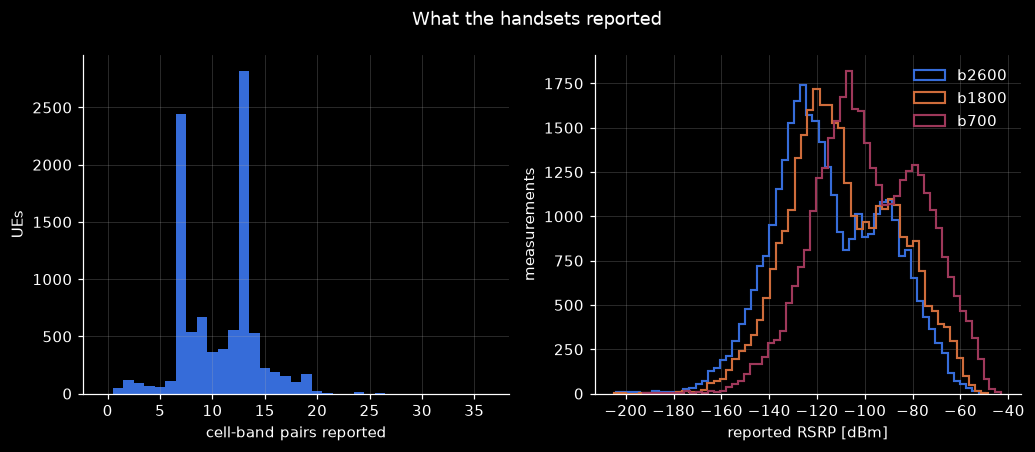

In [23]:
reported = mdt_frame[measurement_columns].notna()

figure, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))
axes[0].hist(reported.sum(axis=1), bins=np.arange(len(measurement_columns) + 2) - 0.5)
axes[0].set_xlabel("cell-band pairs reported")
axes[0].set_ylabel("UEs")
for band in bands:
    columns = [column for column in measurement_columns if column.endswith(f"_{band}")]
    values = mdt_frame[columns].to_numpy().ravel()
    axes[1].hist(values[np.isfinite(values)], bins=60, histtype="step", lw=1.4, label=band)
axes[1].set_xlabel("reported RSRP [dBm]")
axes[1].set_ylabel("measurements")
axes[1].legend()
figure.suptitle("What the handsets reported")
save_fig(figure, "mdt_reported_summary")
plt.show()

### The population the reports came from

Cells go in as transmitters and UEs as receivers, on the perturbed scene. Every
device is drawn as an area emitter, so the UEs are sampled: the whole table would
be slow to trace and would wash the scene out.

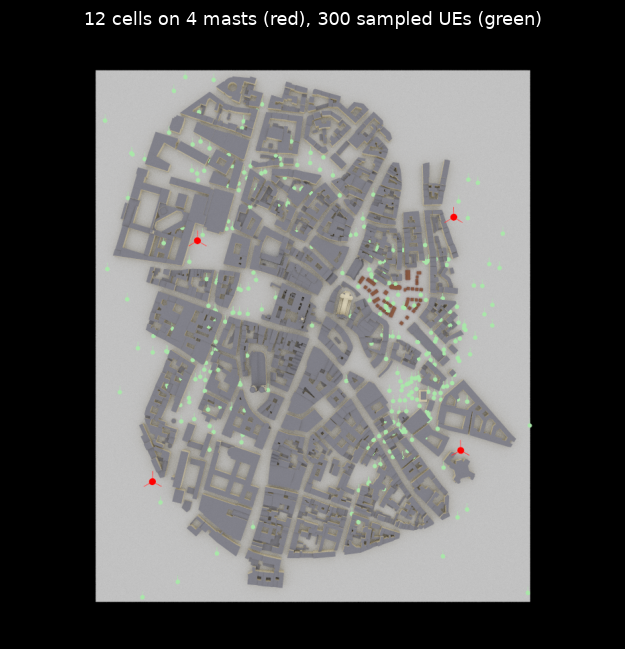

In [24]:
from sionna.rt import Receiver

UE_RENDER_SAMPLE = 300

sample = ue.sample(n=min(UE_RENDER_SAMPLE, len(ue)), random_state=cfg.seed)
n_masts = len({(cell.x, cell.y) for cell in cells})
device_names = [cell.name for cell in cells] + [f"ue{index}" for index in range(len(sample))]
for name in device_names:
    if perturbed_scene.get(name) is not None:
        perturbed_scene.remove(name)

transmitter.build(perturbed_scene, cells, bands[0], float(cfg.simulation.antenna.power_rs))
for index, row in enumerate(sample.itertuples()):
    perturbed_scene.add(
        Receiver(name=f"ue{index}", position=[row.x, row.y, row.z], display_radius=6.0)
    )

render(
    perturbed_scene,
    camera,
    f"{len(cells)} cells on {n_masts} masts (red), {len(sample)} sampled UEs (green)",
    name="scene_devices",
    show_devices=True,
    show_orientations=True,
)

## 6. What was written



These four files are the input to `01_eda.ipynb` and to everything downstream.

In [25]:
pd.DataFrame(
    [
        {
            "stage": stage,
            "file": str(path),
            "exists": Path(path).is_file(),
            "size_mb": round(Path(path).stat().st_size / 1e6, 3) if Path(path).is_file() else None,
        }
        for stage, path in [
            ("scenario", ue_file),
            ("scenario", manifest_file),
            ("radio map", radio_map_file),
            ("mdt", mdt_file),
        ]
    ]
)

,stage,file,exists,size_mb
0,scenario,data\external\ue_positions.csv,True,0.456
1,scenario,data\external\scenario.json,True,0.037
2,radio map,data\interim\radio_map.npz,True,0.229
3,mdt,data\interim\mdt.csv,True,1.559
